# Exploratory Data Analysis (EDA) - Supply Chain Demand Forecasting

This notebook performs exploratory analysis on the **Walmart Sales Forecasting Data Warehouse** in DuckDB (`data/warehouse.duckdb`).

### Key Analysis Objectives:
1. **Data Quality & Integrity**: Check missing values and analyze negative sales (returns).
2. **Feature Coverage**: Evaluate promotional `markdown_total` coverage over time to confirm pre-Nov-2011 data availability limits.
3. **Outlier Detection**: Compute `(store_id, dept_id)` specific z-scores to flag extreme sales spikes and assess promo event overlaps.
4. **Seasonality Patterns**: Visualize weekly sales patterns by store type ($A$, $B$, $C$).
5. **Cleaned Dataset Export**: Save feature-ready DataFrame with `is_outlier` flags to `data/processed/sales_clean.parquet`.


## 0. Environment Setup & Data Ingestion

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)

db_path = Path('../data/warehouse.duckdb')
if not db_path.exists():
    db_path = Path('data/warehouse.duckdb')

conn = duckdb.connect(str(db_path), read_only=True)

query = """
SELECT
    f.store_id,
    f.dept_id,
    f.date,
    f.weekly_sales,
    f.temperature,
    f.fuel_price,
    f.cpi,
    f.unemployment,
    f.markdown_total,
    s.type AS store_type,
    s.size AS store_size,
    d.year,
    d.month,
    d.week AS week_of_year,
    d.day_of_week,
    d.is_promo_event
FROM fact_sales f
JOIN dim_store s ON f.store_id = s.store_id
JOIN dim_date d ON f.date = d.date;
"""

df = conn.execute(query).df()
conn.close()

print(f"Successfully loaded {len(df):,} records into pandas DataFrame.")


Successfully loaded 421,570 records into pandas DataFrame.


## 1. Missing / Negative Data Check

In [2]:
# 1. Calculate missing data percentage per column
null_pct = (df.isnull().mean() * 100).to_frame(name='null_percentage')
print("=== Missing Data Percentage per Column ===")
display(null_pct)

# 2. Identify negative weekly sales (product returns exceeding gross sales)
neg_sales = df[df['weekly_sales'] < 0]
neg_count = len(neg_sales)
neg_pct = (neg_count / len(df)) * 100

print(f"\n=== Negative Weekly Sales Analysis ===")
print(f"Negative Sales Record Count: {neg_count:,} ({neg_pct:.2f}% of total dataset)")
print("\nSample Negative Sales Transactions:")
display(neg_sales[['store_id', 'dept_id', 'date', 'weekly_sales', 'is_promo_event']].head(10))


=== Missing Data Percentage per Column ===


,null_percentage
store_id,0.0
dept_id,0.0
date,0.0
weekly_sales,0.0
temperature,0.0
fuel_price,0.0
cpi,0.0
unemployment,0.0
markdown_total,0.0
store_type,0.0



=== Negative Weekly Sales Analysis ===
Negative Sales Record Count: 1,285 (0.30% of total dataset)

Sample Negative Sales Transactions:


,store_id,dept_id,date,weekly_sales,is_promo_event
2855,13,47,2012-08-10,-98.00,False
3290,13,51,2010-04-09,-14.56,False
3301,13,51,2010-06-25,-53.52,False
3314,13,51,2010-10-01,-11.08,False
3324,13,51,2011-01-14,-21.84,False
3335,13,51,2011-09-23,-14.24,False
3605,13,54,2012-06-29,-10.00,False
4697,25,94,2010-04-23,-4.88,False
4712,25,94,2010-09-10,-4.00,True
4732,25,94,2011-03-04,-18.29,False


## 2. Markdown Coverage Check

> **Data Availability Note**:
> In the Kaggle Walmart Sales dataset, promotional `MarkDown` variables (MarkDown1 through MarkDown5) were only collected starting in **November 2011**. 
> Therefore, weeks prior to November 2011 have `markdown_total = 0` due to a **data collection availability gap**, rather than literal zero-markdown weeks.


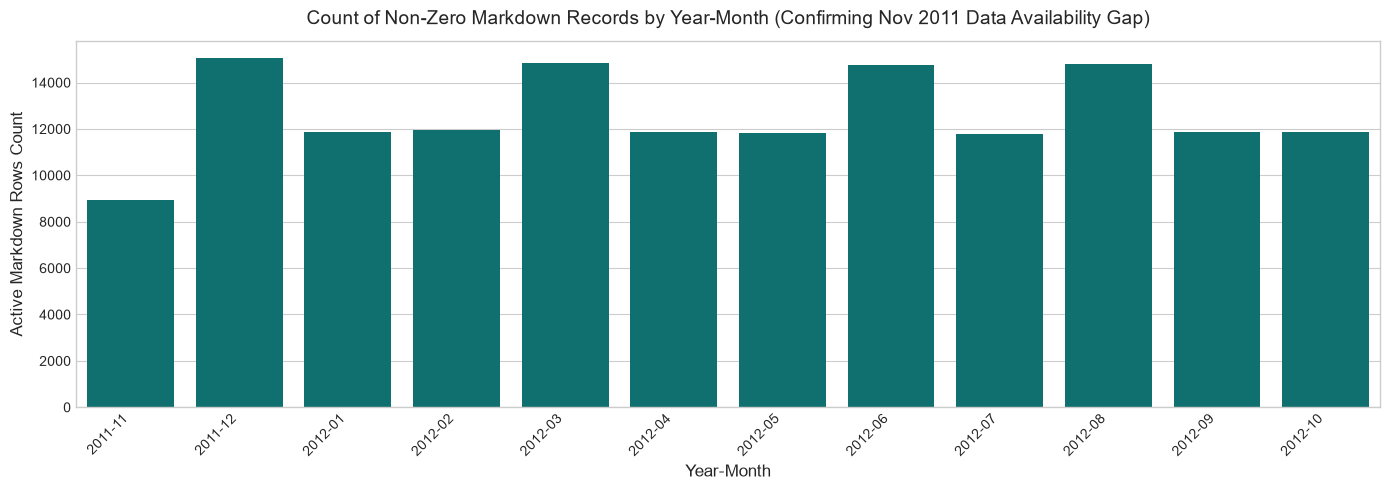

In [3]:
df['year_month'] = df['date'].apply(lambda d: d.strftime('%Y-%m'))

markdown_coverage = (
    df[df['markdown_total'] > 0]
    .groupby('year_month')
    .size()
    .reset_index(name='active_markdown_rows')
)

plt.figure(figsize=(14, 5))
sns.barplot(data=markdown_coverage, x='year_month', y='active_markdown_rows', color='teal')
plt.title('Count of Non-Zero Markdown Records by Year-Month (Confirming Nov 2011 Data Availability Gap)', fontsize=14, pad=12)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Active Markdown Rows Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 3. Outlier Detection (Z-score by Store & Department)

In [4]:
def compute_group_zscore(group):
    std = group.std()
    if pd.isna(std) or std == 0:
        return pd.Series(0.0, index=group.index)
    return (group - group.mean()) / std

df['sales_zscore'] = df.groupby(['store_id', 'dept_id'])['weekly_sales'].transform(compute_group_zscore)
df['is_outlier'] = df['sales_zscore'].abs() > 3

outlier_df = df[df['is_outlier']]
total_outliers = len(outlier_df)
promo_outliers = outlier_df['is_promo_event'].sum()
promo_fraction = (promo_outliers / total_outliers) if total_outliers > 0 else 0.0

print(f"=== Outlier Detection Results ===")
print(f"Total Outliers (|Z| > 3): {total_outliers:,} ({(total_outliers / len(df))*100:.2f}% of all records)")
print(f"Outliers coinciding with Promotional/Holiday Events (is_promo_event = True): {promo_outliers:,}")
print(f"Fraction of Outliers explained by Promo Events: {promo_fraction * 100:.2f}%")


=== Outlier Detection Results ===
Total Outliers (|Z| > 3): 5,945 (1.41% of all records)
Outliers coinciding with Promotional/Holiday Events (is_promo_event = True): 1,060
Fraction of Outliers explained by Promo Events: 17.83%


## 4. Seasonality Visualization (Sales by Week of Year Faceted by Store Type)

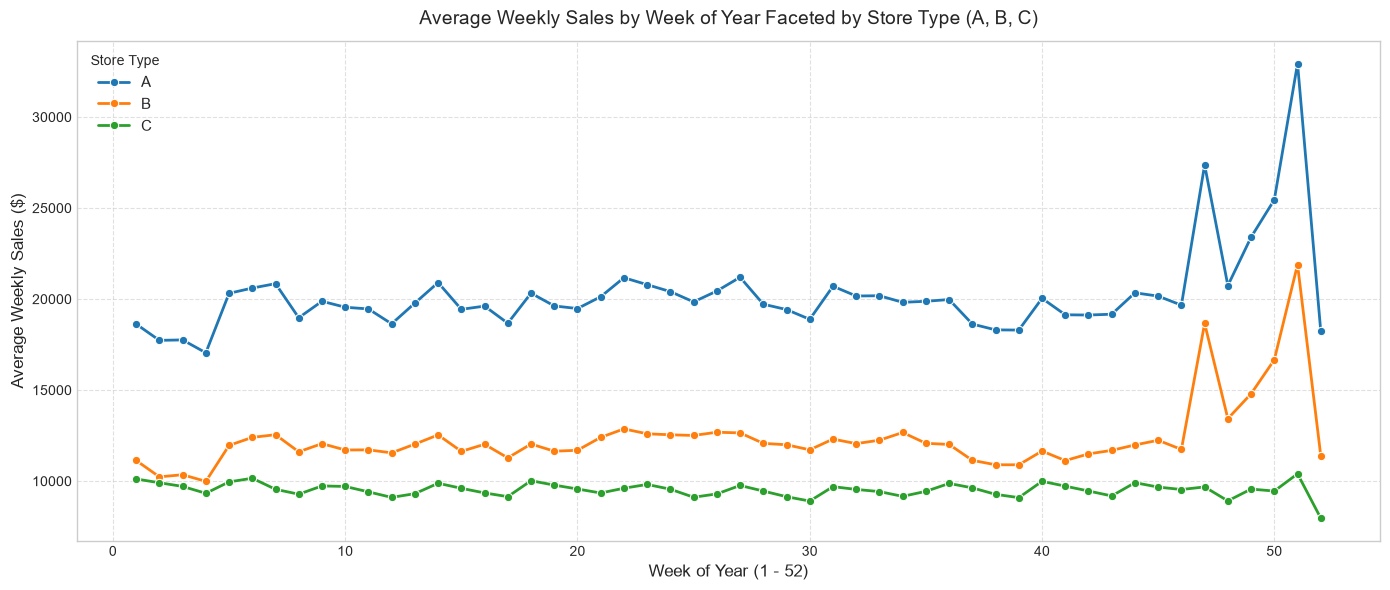

In [5]:
seasonality_df = (
    df.groupby(['store_type', 'week_of_year'])['weekly_sales']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=seasonality_df,
    x='week_of_year',
    y='weekly_sales',
    hue='store_type',
    palette='tab10',
    marker='o',
    linewidth=2
)

plt.title('Average Weekly Sales by Week of Year Faceted by Store Type (A, B, C)', fontsize=14, pad=12)
plt.xlabel('Week of Year (1 - 52)', fontsize=12)
plt.ylabel('Average Weekly Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Store Type', fontsize=11)
plt.tight_layout()
plt.show()


## 5. Export Cleaned & Feature-Ready Dataset

In [6]:
output_dir = Path('../data/processed')
if not output_dir.parent.exists():
    output_dir = Path('data/processed')

output_dir.mkdir(parents=True, exist_ok=True)
parquet_path = output_dir / 'sales_clean.parquet'

df.to_parquet(parquet_path, index=False)

print("=== Parquet Export Confirmation ===")
print(f"Exported Parquet File: {parquet_path.resolve()}")
print(f"Total Rows Saved: {len(df):,}")
print(f"Total Columns Saved: {len(df.columns)}")
print(f"Columns List: {list(df.columns)}")


=== Parquet Export Confirmation ===
Exported Parquet File: D:\Ssshhhh\Projexts\Supply Chain\supply-chain-demand-forecasting\data\processed\sales_clean.parquet
Total Rows Saved: 421,570
Total Columns Saved: 19
Columns List: ['store_id', 'dept_id', 'date', 'weekly_sales', 'temperature', 'fuel_price', 'cpi', 'unemployment', 'markdown_total', 'store_type', 'store_size', 'year', 'month', 'week_of_year', 'day_of_week', 'is_promo_event', 'year_month', 'sales_zscore', 'is_outlier']
